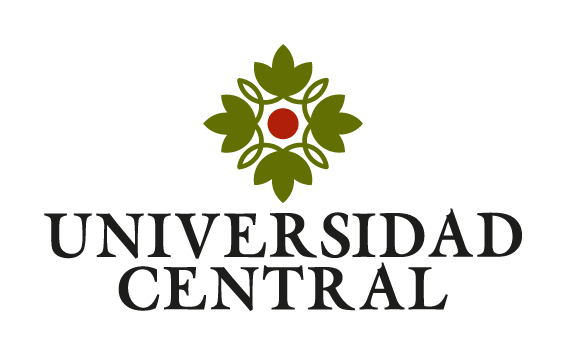

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 30 de 2026

Taller: Trabajo Final

# Etapa 2. Segmentación Inteligente y Generación de Embeddings

Este notebook implementa la **Etapa 2** de la arquitectura del prototipo, ahora con soporte completo para tablas.

## Pipeline
- **Entrada:** JSON normalizados en `Autos_Apertura_Json/`
- **Segmentación:**
  - Bloques jurídicos → chunks de máx. 2048 tokens con **overlap del 20% (≈410 tokens)** → `tipo_chunk='texto'`
  - Tablas anidadas + tablas globales del documento → chunks independientes → `tipo_chunk='tabla'`
  - Filtro de calidad sobre tablas antes de vectorizar
- **Embeddings:** `allenai/longformer-base-4096`, mean pooling, 768 dim
- **Salida:** en `Segmentación/`:

| Archivo | Contenido |
|---|---|
| `chunks_<nombre>.json`  | Chunks por documento (texto + tabla) con trazabilidad completa |
| `embeddings_<nombre>.npy`  | Embeddings 768-d por documento |
| `corpus_chunks_consolidado.json` | Corpus unificado para ChromaDB |
| `corpus_embeddings_consolidado.npy` | Matriz (n_total × 768) |
| `reporte_segmentacion.csv` | Estadísticas por documento (texto vs tabla) |
| `tablas_descartadas.csv` | Log de tablas filtradas por calidad (auditoría) |

## HOJA DE RUTA A SEGUIR

0.  Montar Google Drive
1.  Instalar Dependencias
2.  Instalar Librerias
3.  Configuración de Rutas
4.  Configuración de parámetros de Segmentación y Modelo
5.  Carga del Tokenizer y Modelo Longformer
6.  Limpieza de Ruido (encabezados, pies de página, OCR sucio)
7.  Filtro de Calidad para Tablas
8.  Segmentación de Bloques de Texto
9.  Segmentación de Tablas (anidadas + globales)
10. Generar Embeddings con Longformer
11. Pipeline Principal
12. Corpus Consolidado (entrada para ChromaDB en Etapa 3)
13. Reportes
14. Verificación Rápida de un Chunk (Sanity check)

#0\. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1\. Instalar Dependencias

In [ ]:
!pip install -q transformers==4.44.2 torch sentencepiece tqdm pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.8 MB/s eta 0:00:00


#2\. Instalar Librerias

In [ ]:
import os
import json
import glob
import uuid
import re
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import LongformerTokenizerFast, LongformerModel

#3\. Configuración de Rutas

In [ ]:
INPUT_DIR  = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Autos_Apertura_Json/v4_5pdfs'
OUTPUT_DIR = '/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Entrada: {INPUT_DIR}')
print(f'Salida:  {OUTPUT_DIR}')

Entrada: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Autos_Apertura_Json/v4_5pdfs
Salida:  /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación


# 4\. Configuración de Parámetros de Segmentación y Modelo

In [ ]:
# Segmentación de texto
CHUNK_SIZE     = 2048
OVERLAP_RATIO  = 0.20
OVERLAP_TOKENS = int(CHUNK_SIZE * OVERLAP_RATIO)   # 410
STRIDE         = CHUNK_SIZE - OVERLAP_TOKENS       # 1638

# Modelo
MODEL_NAME    = 'allenai/longformer-base-4096'
MAX_MODEL_LEN = 4096

# Filtro de calidad para tablas
MIN_CHARS_TABLA       = 30       # mínimo de chars útiles tras limpiar
MIN_TOKENS_UNICOS     = 8        # tabla con <8 tokens únicos = basura
MIN_RATIO_DIVERSIDAD  = 0.15     # tokens_únicos / total_tokens; debajo de esto = repetición OCR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

print(f'\nCHUNK_SIZE      = {CHUNK_SIZE} tokens')
print(f'OVERLAP (20%)   = {OVERLAP_TOKENS} tokens')
print(f'STRIDE          = {STRIDE} tokens')

Dispositivo: cuda
GPU: Tesla T4

CHUNK_SIZE      = 2048 tokens
OVERLAP (20%)   = 409 tokens
STRIDE          = 1639 tokens


#5\. Carga del Tokenizer y Modelo Longformer

In [ ]:
print('Cargando tokenizer y modelo Longformer (primera vez puede tardar 1-2 min)...')
tokenizer = LongformerTokenizerFast.from_pretrained(MODEL_NAME)
model     = LongformerModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
print('Modelo cargado correctamente.')

Cargando tokenizer y modelo Longformer (primera vez puede tardar 1-2 min)...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Modelo cargado correctamente.


#6\. Limpieza de Ruido (encabezados, pies de página, OCR sucio)

In [ ]:
PATRONES_RUIDO = [
    r'Oficinas:\s*Carrera\s*13\s*A.*?Email:\s*licencias.*?\.gov\.co',
    r'Centro de Orientación y Radicación de Correspondencia.*?Bogotá,?\s*D\.C\.',
    r'Línea de Orientación y Contacto Ciudadano.*?(?=\s|$)',
    r'PBX:\s*57\s*\(1\)\s*\d+',
    r'www\.anla\.gov\.co',
    r'Nit\.?:\s*900\.467\.239-2',
    r'Código Postal\s*\d+',
    r'Página\s+\d+\s+de\s+\d+',
    r'Hoja\s+No\.\s*\d+\s+de\s+\d+',
    r'Libertad\s+y\s+Orden',
]

def limpiar_texto(texto: str) -> str:
    if not texto:
        return ''
    txt = texto
    for pat in PATRONES_RUIDO:
        txt = re.sub(pat, ' ', txt, flags=re.IGNORECASE | re.DOTALL)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

def limpiar_markdown_tabla(markdown: str) -> str:
    """Quita fences ```, separadores |---|, y normaliza para que el embedding capte semántica."""
    if not markdown:
        return ''
    txt = markdown
    txt = re.sub(r'```[a-zA-Z]*', '', txt)         # fences ```python, ```
    txt = re.sub(r'\|[:\-\s]+\|', ' ', txt)         # filas separadoras |:---|:---|
    txt = txt.replace('|', ' ')                     # pipes
    txt = limpiar_texto(txt)
    return txt

#7\. Filtro de Calidad para Tablas

Descarta tablas con ruido OCR (markdown vacío, dimensiones 0×0, contenido muy corto, baja diversidad léxica).

In [ ]:
def tabla_es_basura(texto_limpio: str, dimensiones: dict) -> tuple:
    """Retorna (es_basura: bool, motivo: str). Aplica varias heurísticas."""
    if not texto_limpio or len(texto_limpio) < MIN_CHARS_TABLA:
        return True, f'menos_de_{MIN_CHARS_TABLA}_chars'

    # Dimensiones vacías o degeneradas
    filas = dimensiones.get('filas') if isinstance(dimensiones, dict) else None
    cols  = dimensiones.get('columnas') if isinstance(dimensiones, dict) else None
    if filas == 0 or cols == 0:
        return True, 'dimensiones_0'

    # Diversidad léxica: tokens_únicos / total_tokens
    palabras = re.findall(r'\w+', texto_limpio.lower())
    if len(palabras) < MIN_TOKENS_UNICOS:
        return True, 'pocas_palabras'
    unicas = len(set(palabras))
    if unicas < MIN_TOKENS_UNICOS:
        return True, 'pocas_palabras_unicas'
    ratio = unicas / len(palabras)
    if ratio < MIN_RATIO_DIVERSIDAD:
        return True, f'baja_diversidad_{ratio:.2f}'

    return False, 'ok'

# Test rápido
print(tabla_es_basura('cumplimiento cumplimiento cumplimiento cumplimiento cumplimiento', {'filas': 5, 'columnas': 1}))
print(tabla_es_basura('Concepto Técnico 1592 del 30 de marzo de 2022 requerimiento mantiene observación titular', {'filas': 4, 'columnas': 3}))

(True, 'pocas_palabras')
(False, 'ok')


#8\. Segmentación de Bloques de Texto

Estrategia:
1. Cada `bloque` del JSON (un numeral jurídico) se trata como unidad mínima.
2. Se tokeniza el texto del bloque (concatenando título + texto).
3. Si cabe en `CHUNK_SIZE` → 1 solo chunk.
4. Si excede → ventana deslizante con `STRIDE` = 1638 tokens, generando chunks con 20% de overlap.
5. Cada chunk hereda los metadatos del bloque original.

In [ ]:
import json

def segmentar_bloque_texto(bloque: dict, doc_meta: dict) -> list:
    """Bloque jurídico → 1+ chunks tipo 'texto' con overlap del 20%."""
    titulo = bloque.get('titulo', '') or ''
    texto  = bloque.get('texto', '') or ''
    contenido = f'{titulo}. {texto}' if titulo else texto
    contenido = limpiar_texto(contenido)

    if not contenido or len(contenido) < 30:
        return []

    token_ids = tokenizer.encode(contenido, add_special_tokens=False)
    n_tokens  = len(token_ids)

    sub_chunks = []
    if n_tokens <= CHUNK_SIZE:
        sub_chunks.append((token_ids, contenido, 0, 1))
    else:
        idx = 0
        start = 0
        while start < n_tokens:
            end = min(start + CHUNK_SIZE, n_tokens)
            sub_ids = token_ids[start:end]
            sub_txt = tokenizer.decode(sub_ids, skip_special_tokens=True)
            sub_chunks.append((sub_ids, sub_txt, idx, None))
            idx += 1
            if end == n_tokens:
                break
            start += STRIDE
        total = len(sub_chunks)
        sub_chunks = [(t, x, i, total) for (t, x, i, _) in sub_chunks]

    out = []
    for token_ids_c, texto_c, idx_c, total_c in sub_chunks:
        # 1. ID Determinista: id_documento + bloque_id + índice
        bloque_id = bloque.get('id', 'noblock')
        doc_id = doc_meta.get('id_documento', 'nodoc')
        deterministic_id = f"{doc_id}_{bloque_id}_txt_{idx_c}"

        # 2. Serialización segura para ChromaDB (no admite diccionarios anidados)
        materias_score_str = json.dumps(doc_meta.get('materias_score', {}))

        out.append({
            'chunk_id': deterministic_id,  # REEMPLAZO DE UUID
            'tipo_chunk': 'texto',
            'id_documento': doc_id,
            'filename': doc_meta.get('filename'),
            'tipo_documento': doc_meta.get('tipo_documento'),
            'numero_documento': doc_meta.get('numero_documento'),
            'fecha_documento': doc_meta.get('fecha_documento'),

            # --- NUEVOS CAMPOS JURIMÉTRICOS INYECTADOS ---
            'empresa': doc_meta.get('empresa'),
            'nit_investigado': doc_meta.get('nit_investigado'),
            'proyecto': doc_meta.get('proyecto'),
            'municipio': doc_meta.get('municipio'),
            'materias_score': materias_score_str,
            # ----------------------------------------------

            'bloque_id': bloque_id,
            'bloque_id_padre': None,
            'numeral': bloque.get('numeral'),
            'tipo_numeral': bloque.get('tipo_numeral'),
            'nivel': bloque.get('nivel'),
            'titulo_bloque': titulo,
            'pagina_inicio': bloque.get('pagina_inicio'),
            'pagina_fin': bloque.get('pagina_fin'),
            'tabla_id': None,
            'tabla_fuente': None,
            'tabla_dimensiones': None,
            'chunk_index': idx_c,
            'total_chunks_bloque': total_c,
            'n_tokens': len(token_ids_c),
            'texto': texto_c,
            'token_ids': token_ids_c,
        })
    return out

# 9\. Segmentación de Tablas (anidadas + globales)

Cada tabla válida → 1 chunk `tipo_chunk='tabla'`. Si el markdown de la tabla excede 2048 tokens, se divide con el mismo overlap del 20%.

In [ ]:
import json

def segmentar_tabla(tabla: dict, doc_meta: dict, bloque_padre: dict = None) -> tuple:
    """
    Devuelve (lista_chunks, motivo_descarte).
    bloque_padre: None para tablas globales; dict del bloque para tablas anidadas.
    """
    markdown = tabla.get('markdown', '') or ''
    titulo_tabla = tabla.get('titulo', '') or ''
    dimensiones  = tabla.get('dimensiones', {}) or {}

    # Limpieza
    contenido = limpiar_markdown_tabla(markdown)
    if titulo_tabla:
        contenido = f'{titulo_tabla}. {contenido}'

    # Filtro de calidad
    basura, motivo = tabla_es_basura(contenido, dimensiones)
    if basura:
        return [], motivo

    # Tokenizar
    token_ids = tokenizer.encode(contenido, add_special_tokens=False)
    n_tokens  = len(token_ids)

    sub_chunks = []
    if n_tokens <= CHUNK_SIZE:
        sub_chunks.append((token_ids, contenido, 0, 1))
    else:
        idx = 0
        start = 0
        while start < n_tokens:
            end = min(start + CHUNK_SIZE, n_tokens)
            sub_ids = token_ids[start:end]
            sub_txt = tokenizer.decode(sub_ids, skip_special_tokens=True)
            sub_chunks.append((sub_ids, sub_txt, idx, None))
            idx += 1
            if end == n_tokens:
                break
            start += STRIDE
        total = len(sub_chunks)
        sub_chunks = [(t, x, i, total) for (t, x, i, _) in sub_chunks]

    bloque_padre_id = bloque_padre.get('id') if bloque_padre else None
    numeral_padre   = bloque_padre.get('numeral') if bloque_padre else tabla.get('seccion')
    titulo_padre    = bloque_padre.get('titulo') if bloque_padre else tabla.get('titulo')
    pagina_ini      = bloque_padre.get('pagina_inicio') if bloque_padre else tabla.get('pagina')
    pagina_fin      = bloque_padre.get('pagina_fin') if bloque_padre else tabla.get('pagina')

    out = []
    for token_ids_c, texto_c, idx_c, total_c in sub_chunks:
        # 1. ID Determinista para TABLAS
        doc_id = doc_meta.get('id_documento', 'nodoc')
        tabla_id = tabla.get('id', 'notab')
        # Usamos '_tab_' para diferenciar visualmente los chunks de tablas de los de texto
        deterministic_id = f"{doc_id}_{tabla_id}_tab_{idx_c}"

        # 2. Serialización segura para ChromaDB (Aplanado de diccionarios)
        materias_score_str = json.dumps(doc_meta.get('materias_score', {}))
        dimensiones_str = json.dumps(dimensiones)  # <--- CRÍTICO: Previene el crasheo en Etapa 3

        out.append({
            'chunk_id': deterministic_id, # REEMPLAZO DE UUID
            'tipo_chunk': 'tabla',
            'id_documento': doc_id,
            'filename': doc_meta.get('filename'),
            'tipo_documento': doc_meta.get('tipo_documento'),
            'numero_documento': doc_meta.get('numero_documento'),
            'fecha_documento': doc_meta.get('fecha_documento'),

            # --- NUEVOS CAMPOS JURIMÉTRICOS INYECTADOS ---
            'empresa': doc_meta.get('empresa'),
            'nit_investigado': doc_meta.get('nit_investigado'),
            'proyecto': doc_meta.get('proyecto'),
            'municipio': doc_meta.get('municipio'),
            'materias_score': materias_score_str,
            # ----------------------------------------------

            'bloque_id': None,
            'bloque_id_padre': bloque_padre_id,   # clave para parent-document retrieval
            'numeral': numeral_padre,
            'tipo_numeral': bloque_padre.get('tipo_numeral') if bloque_padre else 'tabla_global',
            'nivel': bloque_padre.get('nivel') if bloque_padre else None,
            'titulo_bloque': titulo_padre,
            'pagina_inicio': pagina_ini,
            'pagina_fin': pagina_fin,
            'tabla_id': tabla_id,
            'tabla_fuente': tabla.get('fuente'),
            'tabla_dimensiones': dimensiones_str, # REEMPLAZO (De Dict a String)
            'chunk_index': idx_c,
            'total_chunks_bloque': total_c,
            'n_tokens': len(token_ids_c),
            'texto': texto_c,
            'token_ids': token_ids_c,
        })
    return out, 'ok'

#10\. Generar Embeddings con Longformer


In [ ]:
def generar_embedding(token_ids: list) -> np.ndarray:
    ids = [tokenizer.cls_token_id] + list(token_ids) + [tokenizer.sep_token_id]
    if len(ids) > MAX_MODEL_LEN:
        ids = ids[:MAX_MODEL_LEN]

    input_ids = torch.tensor([ids], device=device)
    attention_mask = torch.ones_like(input_ids)
    global_attention_mask = torch.zeros_like(input_ids)
    global_attention_mask[:, 0] = 1

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            global_attention_mask=global_attention_mask,
        )
    last_hidden = outputs.last_hidden_state
    mask = attention_mask.unsqueeze(-1).float()
    summed = (last_hidden * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return (summed / counts).squeeze(0).cpu().numpy().astype(np.float32)

#11\. Pipeline Principal

In [ ]:
archivos_json = sorted(glob.glob(os.path.join(INPUT_DIR, '*.json')))
print(f'JSON encontrados: {len(archivos_json)}')
for f in archivos_json:
    print(f'  - {os.path.basename(f)}')

JSON encontrados: 50
  - 2136_5882_2022-07-27.json
  - 2138_5846_2022-07-26.json
  - 2139_5854_2022-07-26.json
  - 2140_5814_2022-07-25.json
  - 2152_5349_2022-07-13.json
  - 2153_5350_2022-07-13.json
  - 2154_5351_2022-07-13.json
  - 2236_3157_2022-05-05.json
  - 2296_1014_2022-02-28.json
  - 2308_571_2022-02-09.json
  - 2309_577_2022-02-09.json
  - 2310_582_2022-02-09.json
  - 2311_583_2022-02-09.json
  - 2312_589_2022-02-09.json
  - 2330_11096_2023-12-27.json
  - 2403_7378_2023-09-14.json
  - 2404_7381_2023-09-14.json
  - 2405_7384_2023-09-14.json
  - 2407_7336_2023-09-12.json
  - 2411_7195_2023-09-07.json
  - 2456_5935_2023-07-31.json
  - 2462_5707_2023-07-25.json
  - 2463_5718_2023-07-25.json
  - 2464_5749_2023-07-25.json
  - 2514_3158_2023-05-05.json
  - 2515_3159_2023-05-05.json
  - 2525_1964_2023-03-24.json
  - 2526_1966_2023-03-24.json
  - 2527_1967_2023-03-24.json
  - 2546_1449_2023-03-07.json
  - 2554_1092_2023-02-28.json
  - 2799_3668_2024-05-27.json
  - 2824_2702_2024-04-2

In [ ]:
corpus_chunks = []
corpus_embeddings = []
reporte_filas = []
tablas_descartadas_log = []

for ruta_json in archivos_json:
    nombre = os.path.basename(ruta_json).replace('.json', '')
    print(f'\n{"=" * 70}\nProcesando: {nombre}\n{"=" * 70}')

    with open(ruta_json, 'r', encoding='utf-8') as f:
        doc = json.load(f)

    doc_meta = {
        'id_documento': doc.get('id_documento'),
        'filename': doc.get('filename'),
        'tipo_documento': doc.get('tipo_documento'),
        'numero_documento': doc.get('numero_documento'),
        'fecha_documento': doc.get('fecha_documento'),
        # --- NUEVOS CAMPOS JURIMÉTRICOS ---
        'empresa': doc.get('empresa'),
        'nit_investigado': doc.get('nit_investigado'),
        'proyecto': doc.get('proyecto'),
        'municipio': doc.get('municipio'),
        'materias_score': doc.get('materias_score', {}),
    }

    bloques = doc.get('bloques', [])
    tablas_globales = doc.get('tablas', [])
    print(f'Bloques: {len(bloques)}  |  Tablas globales: {len(tablas_globales)}')

    chunks_doc = []
    tablas_ok = 0
    tablas_descartadas = 0

    # 1. Bloques de texto + tablas anidadas
    for bloque in tqdm(bloques, desc='Bloques'):
        chunks_doc.extend(segmentar_bloque_texto(bloque, doc_meta))

        for tabla in bloque.get('tablas_anidadas', []) or []:
            chunks_tabla, motivo = segmentar_tabla(tabla, doc_meta, bloque_padre=bloque)
            if chunks_tabla:
                chunks_doc.extend(chunks_tabla)
                tablas_ok += 1
            else:
                tablas_descartadas += 1
                tablas_descartadas_log.append({
                    'archivo': nombre, 'tabla_id': tabla.get('id'),
                    'tipo': 'anidada', 'motivo': motivo,
                })

    # 2. Tablas globales del documento
    for tabla in tqdm(tablas_globales, desc='Tablas globales'):
        chunks_tabla, motivo = segmentar_tabla(tabla, doc_meta, bloque_padre=None)
        if chunks_tabla:
            chunks_doc.extend(chunks_tabla)
            tablas_ok += 1
        else:
            tablas_descartadas += 1
            tablas_descartadas_log.append({
                'archivo': nombre, 'tabla_id': tabla.get('id'),
                'tipo': 'global', 'motivo': motivo,
            })

    print(f'Chunks generados: {len(chunks_doc)}  '
          f'(texto: {sum(1 for c in chunks_doc if c["tipo_chunk"]=="texto")}, '
          f'tabla: {sum(1 for c in chunks_doc if c["tipo_chunk"]=="tabla")})')
    print(f'Tablas: {tablas_ok} OK, {tablas_descartadas} descartadas por filtro de calidad')

    if not chunks_doc:
        print('⚠ Sin chunks, se omite documento.')
        continue

    # 3. Embeddings
    embeddings_doc = np.zeros((len(chunks_doc), 768), dtype=np.float32)
    for i, ch in enumerate(tqdm(chunks_doc, desc='Embeddings')):
        embeddings_doc[i] = generar_embedding(ch['token_ids'])

    # 4. Guardado por documento
    chunks_serializables = [{k: v for k, v in ch.items() if k != 'token_ids'} for ch in chunks_doc]

    ruta_chunks = os.path.join(OUTPUT_DIR, f'chunks_{nombre}.json')
    with open(ruta_chunks, 'w', encoding='utf-8') as f:
        json.dump({
            'documento': doc_meta,
            'parametros': {
                'modelo': MODEL_NAME,
                'chunk_size_tokens': CHUNK_SIZE,
                'overlap_ratio': OVERLAP_RATIO,
                'overlap_tokens': OVERLAP_TOKENS,
                'stride': STRIDE,
                'min_chars_tabla': MIN_CHARS_TABLA,
                'min_tokens_unicos': MIN_TOKENS_UNICOS,
                'min_ratio_diversidad': MIN_RATIO_DIVERSIDAD,
            },
            'total_chunks': len(chunks_serializables),
            'chunks': chunks_serializables,
        }, f, ensure_ascii=False, indent=2)

    ruta_emb = os.path.join(OUTPUT_DIR, f'embeddings_{nombre}.npy')
    np.save(ruta_emb, embeddings_doc)

    print(f'✓ {ruta_chunks}')
    print(f'✓ {ruta_emb}  shape={embeddings_doc.shape}')

    corpus_chunks.extend(chunks_serializables)
    corpus_embeddings.append(embeddings_doc)

    reporte_filas.append({
        'archivo': nombre,
        'bloques_originales': len(bloques),
        'tablas_globales_originales': len(tablas_globales),
        'chunks_texto': sum(1 for c in chunks_doc if c['tipo_chunk']=='texto'),
        'chunks_tabla': sum(1 for c in chunks_doc if c['tipo_chunk']=='tabla'),
        'chunks_total': len(chunks_doc),
        'tablas_ok': tablas_ok,
        'tablas_descartadas': tablas_descartadas,
        'tokens_promedio': round(np.mean([c['n_tokens'] for c in chunks_doc]), 1),
        'tokens_max': max(c['n_tokens'] for c in chunks_doc),
    })


Procesando: 2136_5882_2022-07-27
Bloques: 8  |  Tablas globales: 0


Bloques:   0%|          | 0/8 [00:00<?, ?it/s]

Tablas globales: 0it [00:00, ?it/s]

Chunks generados: 8  (texto: 8, tabla: 0)
Tablas: 0 OK, 0 descartadas por filtro de calidad


Embeddings:   0%|          | 0/8 [00:00<?, ?it/s]

...

Bloques:   0%|          | 0/13 [00:00<?, ?it/s]

Tablas globales:   0%|          | 0/13 [00:00<?, ?it/s]

Chunks generados: 39  (texto: 13, tabla: 26)
Tablas: 26 OK, 0 descartadas por filtro de calidad


Embeddings:   0%|          | 0/39 [00:00<?, ?it/s]

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/chunks_2897_184_2024-01-18.json
✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/embeddings_2897_184_2024-01-18.npy  shape=(39, 768)


#12\. Corpus Consolidado (entrada para ChromaDB en Etapa 3)

In [ ]:
if corpus_embeddings:
    corpus_matrix = np.vstack(corpus_embeddings)

    ruta_corpus_json = os.path.join(OUTPUT_DIR, 'corpus_chunks_consolidado.json')
    with open(ruta_corpus_json, 'w', encoding='utf-8') as f:
        json.dump({
            'parametros': {
                'modelo': MODEL_NAME,
                'chunk_size_tokens': CHUNK_SIZE,
                'overlap_ratio': OVERLAP_RATIO,
                'overlap_tokens': OVERLAP_TOKENS,
            },
            'total_documentos': len(archivos_json),
            'total_chunks': len(corpus_chunks),
            'chunks_texto': sum(1 for c in corpus_chunks if c['tipo_chunk']=='texto'),
            'chunks_tabla': sum(1 for c in corpus_chunks if c['tipo_chunk']=='tabla'),
            'dim_embedding': int(corpus_matrix.shape[1]),
            'chunks': corpus_chunks,
        }, f, ensure_ascii=False, indent=2)

    ruta_corpus_npy = os.path.join(OUTPUT_DIR, 'corpus_embeddings_consolidado.npy')
    np.save(ruta_corpus_npy, corpus_matrix)

    print(f'✓ {ruta_corpus_json}')
    print(f'✓ {ruta_corpus_npy}  shape={corpus_matrix.shape}')

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/corpus_chunks_consolidado.json
✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/corpus_embeddings_consolidado.npy  shape=(1320, 768)


# 13\. Reportes

In [ ]:
# Reporte principal
df_reporte = pd.DataFrame(reporte_filas)
ruta_reporte = os.path.join(OUTPUT_DIR, 'reporte_segmentacion.csv')
df_reporte.to_csv(ruta_reporte, index=False, encoding='utf-8')
print(f'✓ {ruta_reporte}\n')
df_reporte

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/reporte_segmentacion.csv



,archivo,bloques_originales,tablas_globales_originales,chunks_texto,chunks_tabla,chunks_total,tablas_ok,tablas_descartadas,tokens_promedio,tokens_max
0,2136_5882_2022-07-27,8,0,8,0,8,0,0,798.8,1503
1,2138_5846_2022-07-26,16,0,16,0,16,0,0,683.0,1561
2,2139_5854_2022-07-26,11,1,12,2,14,2,0,691.9,2048
3,2140_5814_2022-07-25,13,0,14,0,14,0,0,579.1,2048
4,2152_5349_2022-07-13,18,2,18,2,20,2,2,582.3,1398
5,2153_5350_2022-07-13,12,2,14,4,18,4,0,868.7,2048
6,2154_5351_2022-07-13,14,0,14,0,14,0,0,515.9,1236
7,2236_3157_2022-05-05,10,16,16,30,46,30,2,605.5,2048
8,2296_1014_2022-02-28,10,0,10,0,10,0,0,501.8,1591
9,2308_571_2022-02-09,9,0,10,0,10,0,0,728.2,2048


In [ ]:
# Log de tablas descartadas (útil para debugging)
if tablas_descartadas_log:
    df_descartes = pd.DataFrame(tablas_descartadas_log)
    ruta_descartes = os.path.join(OUTPUT_DIR, 'tablas_descartadas.csv')
    df_descartes.to_csv(ruta_descartes, index=False, encoding='utf-8')
    print(f'✓ {ruta_descartes}')
    print(f'\nMotivos de descarte:')
    print(df_descartes['motivo'].value_counts())
else:
    print('No hubo tablas descartadas.')

✓ /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Segmentación/tablas_descartadas.csv

Motivos de descarte:
motivo
baja_diversidad_0.08    2
baja_diversidad_0.13    2
Name: count, dtype: int64


In [ ]:
# Resumen global
if reporte_filas:
    print('=' * 60)
    print('RESUMEN GLOBAL — ETAPA 2')
    print('=' * 60)
    print(f'Documentos:                      {len(df_reporte)}')
    print(f'Bloques jurídicos:               {df_reporte["bloques_originales"].sum()}')
    print(f'Tablas originales (globales):    {df_reporte["tablas_globales_originales"].sum()}')
    print(f'Chunks de texto:                 {df_reporte["chunks_texto"].sum()}')
    print(f'Chunks de tabla:                 {df_reporte["chunks_tabla"].sum()}')
    print(f'Chunks totales (entrada RAG):    {df_reporte["chunks_total"].sum()}')
    print(f'Tablas válidas:                  {df_reporte["tablas_ok"].sum()}')
    print(f'Tablas descartadas por filtro:   {df_reporte["tablas_descartadas"].sum()}')
    print(f'Modelo:                          {MODEL_NAME}')
    print(f'Dim. embedding:                  768')
    print(f'Overlap:                         {OVERLAP_RATIO*100:.0f}% ({OVERLAP_TOKENS} tokens)')

RESUMEN GLOBAL — ETAPA 2
Documentos:                      50
Bloques jurídicos:               893
Tablas originales (globales):    170
Chunks de texto:                 984
Chunks de tabla:                 336
Chunks totales (entrada RAG):    1320
Tablas válidas:                  336
Tablas descartadas por filtro:   4
Modelo:                          allenai/longformer-base-4096
Dim. embedding:                  768
Overlap:                         20% (409 tokens)


#14\. Verificación Rápida de un Chunk (Sanity check)

In [ ]:
if corpus_chunks:
    # Un chunk de texto y uno de tabla
    ej_texto = next((c for c in corpus_chunks if c['tipo_chunk']=='texto'), None)
    ej_tabla = next((c for c in corpus_chunks if c['tipo_chunk']=='tabla'), None)

    for label, ej in [('TEXTO', ej_texto), ('TABLA', ej_tabla)]:
        if ej is None:
            continue
        print(f'\n--- Ejemplo chunk {label} ---')
        for k, v in ej.items():
            if k == 'texto':
                print(f'{k}: {str(v)[:250]}...')
            else:
                print(f'{k}: {v}')


--- Ejemplo chunk TEXTO ---
chunk_id: AUTO_005882_2022-07-27_AUTO_005882_2022-07-27_blk_0000_txt_0
tipo_chunk: texto
id_documento: AUTO_005882_2022-07-27
filename: 2136_5882_2022-07-27.pdf
tipo_documento: AUTO
numero_documento: 5882
fecha_documento: 2022-07-27
empresa: Petróleos Sudamericanos Energy Sucursal Colombia
nit_investigado: 900.495.129-1
proyecto: Área Adicionada del Bloque El Difícil - AABD
municipio: Ariguaní
materias_score: {"contingencias_ambientales": 2, "obligaciones_seguimiento_ica": 10, "compensacion_inversion": 13}
bloque_id: AUTO_005882_2022-07-27_blk_0000
bloque_id_padre: None
numeral: INTRO
tipo_numeral: intro
nivel: 0
titulo_bloque: ENCABEZADO Y PROEMIO
pagina_inicio: 1
pagina_fin: 1
tabla_id: None
tabla_fuente: None
tabla_dimensiones: None
chunk_index: 0
total_chunks_bloque: 1
n_tokens: 306
texto: ENCABEZADO Y PROEMIO. República de Colombia Ministerio de Ambiente y Desarrollo Sostenible AUTORIDAD NACIONAL DE LICENCIAS AMBIENTALES - ANLA – AUTO N° 05882 ( 27 de 